In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# This cell imports all the necessary libraries for data manipulation, visualization, machine learning, and model evaluation.
# It also sets up warning suppression to keep the output cleaner.
# This does not directly affect the data but sets up the environment for subsequent operations.

In [2]:
df = pd.read_csv("/content/Salary_dataset.csv") # Loads the dataset from the CSV file into a pandas DataFrame.
df # Displays the entire DataFrame.

# This cell reads the raw data into a DataFrame named 'df'. This is the initial loading of the dataset,
# making the data available for analysis and further processing in the notebook.

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


**View Dataset**

In [ ]:
df.head() # Displays the first 5 rows of the DataFrame.

# This cell shows the top rows of the DataFrame, which is useful for a quick visual inspection of the data's structure and content.
# It does not modify the data.

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [ ]:
df.tail() # Displays the last 5 rows of the DataFrame.

# This cell shows the bottom rows of the DataFrame, providing another quick look at the data.
# It does not modify the data.

,Unnamed: 0,YearsExperience,Salary
25,25,9.1,105583.0
26,26,9.6,116970.0
27,27,9.7,112636.0
28,28,10.4,122392.0
29,29,10.6,121873.0


In [ ]:
df.sample(5) # Displays 5 random rows from the DataFrame.

# This cell selects and displays 5 random rows, which can help in getting a diverse view of the data without loading the entire dataset.
# It does not modify the data.

,Unnamed: 0,YearsExperience,Salary
28,28,10.4,122392.0
15,15,5.0,67939.0
29,29,10.6,121873.0
25,25,9.1,105583.0
1,1,1.4,46206.0


**Dataset Information**

In [ ]:
df.info() # Prints a summary of the DataFrame including data types and non-null values.

# This cell provides a concise summary of the DataFrame, showing the number of entries, columns, non-null values per column, and data types.
# This helps in identifying missing data or incorrect data types, but does not alter the data itself.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [ ]:
df.shape # Returns a tuple representing the dimensionality of the DataFrame (rows, columns).

# This cell shows the number of rows and columns in the DataFrame, which is essential for understanding the size of the dataset.
# It does not modify the data.

(30, 3)

In [ ]:
df.columns # Displays the column names of the DataFrame.

# This cell lists all the column names, which is useful for referencing specific features during analysis.
# It does not modify the data.

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [ ]:
df.describe() # Generates descriptive statistics of the DataFrame's numerical columns.

# This cell provides statistical insights like mean, standard deviation, min, max, and quartiles for numerical columns.
# This helps in understanding the distribution and central tendency of the data but does not modify it.

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [ ]:
# This cell is currently empty and has no effect on the data.

In [ ]:
# This cell is currently empty and has no effect on the data.

**Check Missing Values**

In [3]:
df.isnull().sum() # Calculates the sum of null (missing) values for each column.

# This cell identifies and quantifies missing values in each column. This is a crucial step in data cleaning.
# It does not modify the data but provides information for potential data imputation or deletion in later steps.

,0
Unnamed: 0,0
YearsExperience,0
Salary,0


**Check Duplicate Rows**

In [4]:
df.duplicated().sum() # Counts the number of duplicate rows in the DataFrame.

# If duplicates exist
# df.drop_duplicates(inplace=True) # Removes duplicate rows from the DataFrame in-place.

# This cell checks for duplicate rows. If duplicates were found and the commented line was uncommented and executed,
# it would reduce the number of rows in the DataFrame by removing redundant entries, thereby affecting the dataset's size and potentially its statistical properties.

np.int64(0)

**Correlation**

In [ ]:
df.corr(numeric_only=True) # Computes the pairwise correlation between numerical columns.

# This cell calculates the correlation matrix for numerical columns. This shows the linear relationship between variables.
# It does not modify the data but provides insights into feature relationships, which can be important for feature selection in modeling.

,Unnamed: 0,YearsExperience,Salary
Unnamed: 0,1.000000,0.986460,0.960826
YearsExperience,0.986460,1.000000,0.978242
Salary,0.960826,0.978242,1.000000


**Visualize Correlation**

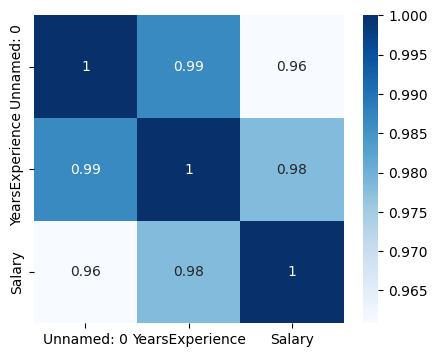

In [5]:
plt.figure(figsize=(5,4)) # Creates a new figure with a specified size.

sns.heatmap(df.corr(numeric_only=True),
            annot=True, # Annotates the heatmap with the correlation values.
            cmap="Blues") # Sets the color map for the heatmap.

plt.show() # Displays the plot.

# This cell visualizes the correlation matrix using a heatmap. This makes it easier to interpret the strength and direction of relationships between variables.
# It does not modify the data.
#Darker the color stronger the relationship

**Scatter Plot**

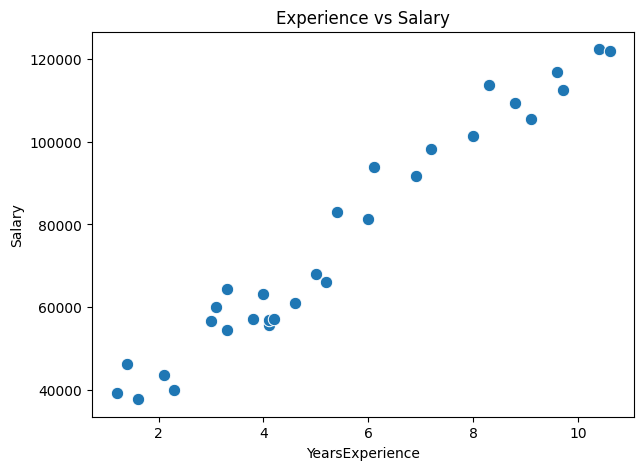

In [6]:
plt.figure(figsize=(7,5)) # Creates a new figure for the plot.

sns.scatterplot(
    x="YearsExperience", # Sets 'YearsExperience' as the x-axis variable.
    y="Salary", # Sets 'Salary' as the y-axis variable.
    data=df, # Specifies the DataFrame to use.
    s=80 # Sets the size of the markers.
)

plt.title("Experience vs Salary") # Sets the title of the plot.

plt.show() # Displays the plot.

# This cell generates a scatter plot to visualize the relationship between 'YearsExperience' and 'Salary'.
# This helps in visually identifying patterns, trends, and potential outliers between these two variables.
# It does not modify the data.

**Define Features and Target**

In [7]:
#The Goal is to predict y values based on x values means salary based on years of expereince.
# Independent Variable
# X → Input
X = df[["YearsExperience"]] # Selects 'YearsExperience' as the independent variable (feature).
X # Displays the independent variable DataFrame.

# This cell extracts the 'YearsExperience' column to be used as the input feature (X) for the model.
# This creates a new DataFrame 'X', which is a subset of the original 'df', affecting how data is used in modeling.

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [8]:
# Dependent Variable
# y → Output
y = df["Salary"] # Selects 'Salary' as the dependent variable (target).
y # Displays the dependent variable Series.

# This cell extracts the 'Salary' column to be used as the target variable (y) for the model.
# This creates a new Series 'y', which is also a subset of the original 'df', affecting how data is used in modeling.

,Salary
0,39344.0
1,46206.0
2,37732.0
3,43526.0
4,39892.0
5,56643.0
6,60151.0
7,54446.0
8,64446.0
9,57190.0


**Train-Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, # Independent variable data.
    y, # Dependent variable data.
    test_size=0.2, # Allocates 20% of the data for testing.
    random_state=42 # Sets a seed for reproducibility.
)

# This cell splits the dataset into training and testing sets for both independent (X) and dependent (y) variables.
# This step is crucial for evaluating the model's performance on unseen data, affecting how the model learns and is validated.
# It partitions the existing data without altering its values.

**Check Shapes**

In [11]:
print(X_train.shape) # Prints the shape (rows, columns) of the training features.

print(X_test.shape) # Prints the shape of the testing features.

print(y_train.shape) # Prints the shape of the training target.

print(y_test.shape) # Prints the shape of the testing target.

# This cell verifies the dimensions of the newly created training and testing sets.
# It confirms the successful partitioning of the data, which is important for ensuring the model training and evaluation process is correctly set up.
# It does not modify the data.

(24, 1)
(6, 1)
(24,)
(6,)


**Create Model**

In [12]:
model = LinearRegression() # Initializes a Linear Regression model.

# This cell creates an instance of the LinearRegression model, preparing it for training.
# It does not affect the data directly but sets up the model that will learn from the data.

**Train Model**

In [13]:
# model learns-> Salary = mX + b
model.fit(X_train, y_train) # Trains the model using the training features (X_train) and training target (y_train).

# This cell trains the Linear Regression model using the training data.
# During this process, the model learns the optimal coefficients (slope 'm') and intercept ('b') that best fit the relationship between 'YearsExperience' and 'Salary' in the training data.
# This is a fundamental step in machine learning, where the model's internal parameters are adjusted based on the data.

LinearRegression()

**Model Parameters**

In [14]:
# Slope
print(model.coef_) # Prints the coefficient (slope) learned by the model.

# This cell displays the slope (coefficient) of the linear regression model.
# This value represents how much 'Salary' is expected to change for every one-unit increase in 'YearsExperience'.
# It provides insight into the learned relationship from the data but does not modify the data itself.

[9423.81532303]


In [15]:
# Intercept
print(model.intercept_) # Prints the intercept learned by the model.

# This cell displays the intercept of the linear regression model.
# This value represents the predicted 'Salary' when 'YearsExperience' is zero. In some contexts, it can be interpreted as a baseline salary.
# It provides further insight into the learned relationship from the data but does not modify the data itself.

24380.201479473704


**Predict**

In [16]:
y_pred = model.predict(X_test)
 # Uses the trained model to make predictions on the test features.
y_pred
# This cell uses the trained model to generate salary predictions based on the 'YearsExperience' values in the test set.
# This creates a new array of predicted values (`y_pred`), which are derived from the model's learning on the training data. This is a transformation of the input `X_test` into `y_pred` based on the model's parameters.

array([115791.21011287,  71499.27809463, 102597.86866063,  75268.80422384,
        55478.79204548,  60190.69970699])

**Compare Actual vs Prediction**

In [17]:
comparison = pd.DataFrame({
    "Actual": y_test, # Actual salary values from the test set.
    "Predicted": y_pred # Predicted salary values from the model.
})

comparison # Displays the comparison DataFrame.

# This cell creates a DataFrame to easily compare the actual salaries from the test set with the salaries predicted by the model.
# This helps in visually assessing the model's accuracy on individual data points, without modifying the original data.

,Actual,Predicted
27,112636.0,115791.210113
15,67939.0,71499.278095
23,113813.0,102597.868661
17,83089.0,75268.804224
8,64446.0,55478.792045
9,57190.0,60190.699707


**Visualize Prediction**

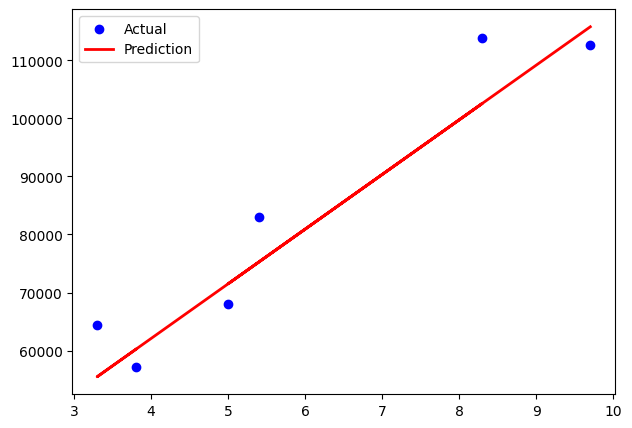

In [18]:
plt.figure(figsize=(7,5)) # Creates a new figure for the plot.

plt.scatter(
    X_test, # 'YearsExperience' from the test set.
    y_test, # Actual 'Salary' from the test set.
    color="blue", # Color for actual data points.
    label="Actual"
)

plt.plot(
    X_test, # 'YearsExperience' from the test set.
    y_pred, # Predicted 'Salary' values.
    color="red", # Color for the prediction line.
    linewidth=2, # Width of the prediction line.
    label="Prediction"
)

plt.legend() # Displays the legend for the plot.

plt.show() # Displays the plot.

# This cell visualizes the actual vs. predicted salaries on the test set.
# The scatter points represent the actual data, and the red line represents the model's linear prediction.
# This helps in understanding how well the model captures the trend in the data and its overall fit. It does not modify the data.

**Predict New Salary**

In [19]:
experience = [[6]] # Defines a new experience value for prediction.

prediction = model.predict(experience) # Predicts the salary for the new experience value.

print(prediction) # Prints the predicted salary.

# This cell demonstrates how to use the trained model to predict the salary for a new, unseen 'YearsExperience' value.
# This applies the learned model to new input, producing a new output based on the model's parameters. It does not modify the original dataset, but rather uses the model derived from it.

[80923.09341766]


**Save Model**

In [ ]:
import joblib # Imports the joblib library for saving and loading Python objects efficiently.

joblib.dump(model, "salary_model.pkl") # Saves the trained model to a file named "salary_model.pkl".

# This cell saves the trained machine learning model to a file using `joblib`.
# This allows the model to be reused later without needing to retrain it, making it persistent.
# It does not affect the data in the notebook, but creates an external file that encapsulates the learned model.

['salary_model.pkl']

**Load Model**

In [ ]:
loaded_model = joblib.load("salary_model.pkl") # Loads the saved model from the file.

# This cell loads the previously saved model from the "salary_model.pkl" file back into memory.
# This allows for the use of the trained model without retraining, demonstrating portability.
# It does not modify the data in the notebook, but brings a pre-trained model into the current session.

**Predict Again**

In [ ]:
loaded_model.predict([[10]]) # Uses the loaded model to predict the salary for 10 years of experience.

# This cell uses the newly loaded model to make another prediction for a specific 'YearsExperience' value.
# This confirms that the loaded model functions correctly and produces consistent predictions, similar to the original model.
# It does not modify the data.

array([118618.35470978])

**Model Evaluation**

In [ ]:
#we already have y_test and y_pred

# This cell is a comment indicating that the necessary variables for model evaluation (y_test and y_pred) are already available.
# It does not perform any operation on the data.

**Mean Absolute Error (MAE)**

In [ ]:
mae = mean_absolute_error(y_test, y_pred) # Calculates the Mean Absolute Error.

print("MAE =", mae)   #Average prediction error.

# Lower MAE means better model

# This cell calculates the Mean Absolute Error (MAE), which is the average of the absolute differences between actual and predicted values.
# MAE provides a measure of the average magnitude of the errors, indicating how far off the predictions are on average.
# It assesses the model's performance based on the `y_test` and `y_pred` data but does not modify the original dataset.

MAE = 6286.453830757745


**Mean Squared Error (MSE)**

In [ ]:
mse = mean_squared_error(y_test, y_pred) # Calculates the Mean Squared Error.

print("MSE =", mse)
#Squares larger errors, penalizing them more heavily.
#Lower MSE is better again.
# This cell calculates the Mean Squared Error (MSE), which is the average of the squared differences between actual and predicted values.
# MSE penalizes larger errors more heavily than MAE, making it sensitive to outliers. It quantifies the average squared magnitude of the errors.
# It assesses the model's performance based on the `y_test` and `y_pred` data but does not modify the original dataset.

MSE = 49830096.855908394


**Root Mean Squared Error (RMSE)**

In [ ]:
rmse = np.sqrt(mse) # Calculates the Root Mean Squared Error.

print("RMSE =", rmse)

#Lower RMSE is better again.
# This cell calculates the Root Mean Squared Error (RMSE), which is the square root of the MSE.
# RMSE is often preferred over MSE because it is in the same units as the target variable, making it more interpretable.
# It provides a measure of the typical magnitude of the prediction errors, similar to MAE, but with sensitivity to larger errors.
# It assesses the model's performance based on the `y_test` and `y_pred` data but does not modify the original dataset.

RMSE = 7059.04362190151


**R² Score**

In [ ]:
r2 = r2_score(y_test, y_pred) # Calculates the R-squared score.

print("R2 Score =", r2)    #Closer to 1 = Better Model

# This cell calculates the R-squared (R²) score, which represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s).
# An R² score closer to 1 indicates a better fit of the model to the data. It's a measure of how well the model explains the variability in the target variable.
# It assesses the model's performance based on the `y_test` and `y_pred` data but does not modify the original dataset.

R2 Score = 0.9024461774180497


**Display All Metrics**

In [ ]:
print(f"MAE  : {mae:.2f}") # Prints the MAE, formatted to two decimal places.
print(f"MSE  : {mse:.2f}") # Prints the MSE, formatted to two decimal places.
print(f"RMSE : {rmse:.2f}") # Prints the RMSE, formatted to two decimal places.
print(f"R²   : {r2:.2f}") # Prints the R² score, formatted to two decimal places.

# This cell consolidates and displays all the calculated evaluation metrics in a formatted output.
# It provides a quick summary of the model's performance across different metrics, allowing for a comprehensive assessment.
# It does not modify the data.

MAE  : 6286.45
MSE  : 49830096.86
RMSE : 7059.04
R²   : 0.90


**Residual Errors**

In [ ]:
residuals = y_test - y_pred # Calculates the difference between actual and predicted values.

residuals # Displays the residual errors.

# This cell calculates the residual errors by subtracting the predicted salaries from the actual salaries in the test set.
# Residuals represent the errors or unexplained variance by the model. Analyzing them can reveal patterns of systematic error or outliers.
# This creates a new Series `residuals` based on `y_test` and `y_pred`, but does not modify the original dataset.

,Salary
27,-3155.210113
15,-3560.278095
23,11215.131339
17,7820.195776
8,8967.207955
9,-3000.699707


**Residual Plot**

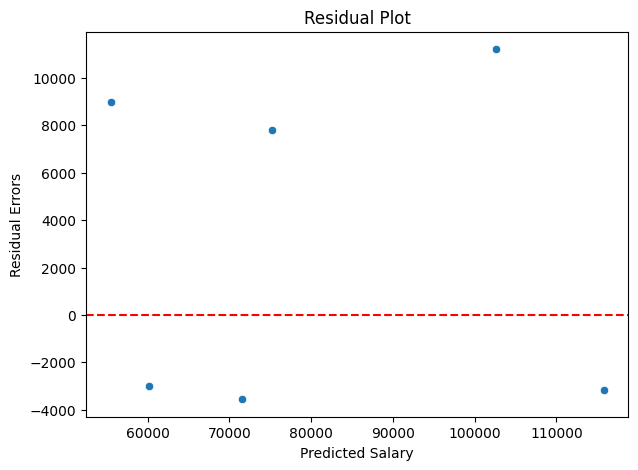

In [ ]:
plt.figure(figsize=(7,5)) # Creates a new figure for the plot.

sns.scatterplot(
    x=y_pred, # Predicted values on the x-axis.
    y=residuals # Residual errors on the y-axis.
)

plt.axhline(
    y=0, # Draws a horizontal line at y=0.
    color="red", # Color of the line.
    linestyle="--" # Style of the line.
)

plt.xlabel("Predicted Salary") # Sets the x-axis label.
plt.ylabel("Residual Errors") # Sets the y-axis label.
plt.title("Residual Plot") # Sets the title of the plot.

plt.show() # Displays the plot.

# This cell generates a residual plot, which visualizes the distribution of residuals against the predicted values.
# An ideal residual plot shows a random scatter of points around the zero line, indicating that the model's errors are random and normally distributed.
# Patterns in this plot can suggest issues like heteroscedasticity or non-linearity, which would affect the model's reliability. It does not modify the data.

**Actual vs Predicted Plot**

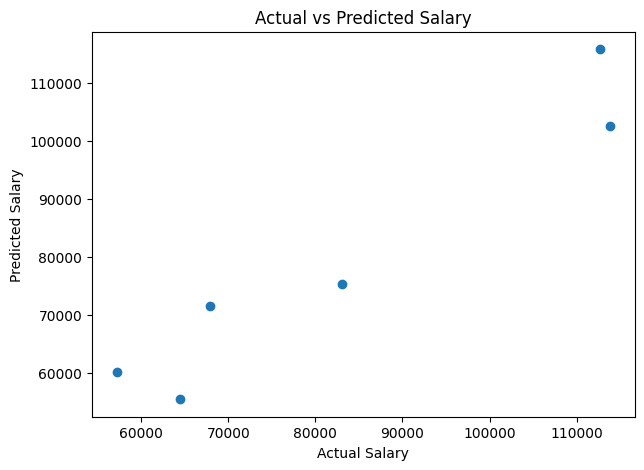

In [ ]:
plt.figure(figsize=(7,5)) # Creates a new figure for the plot.

plt.scatter(
    y_test, # Actual salaries on the x-axis.
    y_pred # Predicted salaries on the y-axis.
)

plt.xlabel("Actual Salary") # Sets the x-axis label.
plt.ylabel("Predicted Salary") # Sets the y-axis label.
plt.title("Actual vs Predicted Salary") # Sets the title of the plot.

plt.show() # Displays the plot.

# This cell creates a scatter plot comparing the actual salaries with the predicted salaries.
# Ideally, the points should fall close to a 45-degree line, indicating that the predicted values are very close to the actual values.
# This plot provides a visual representation of the model's overall accuracy and consistency across the range of salaries. It does not modify the data.

In [ ]:
# This cell is currently empty and has no effect on the data.